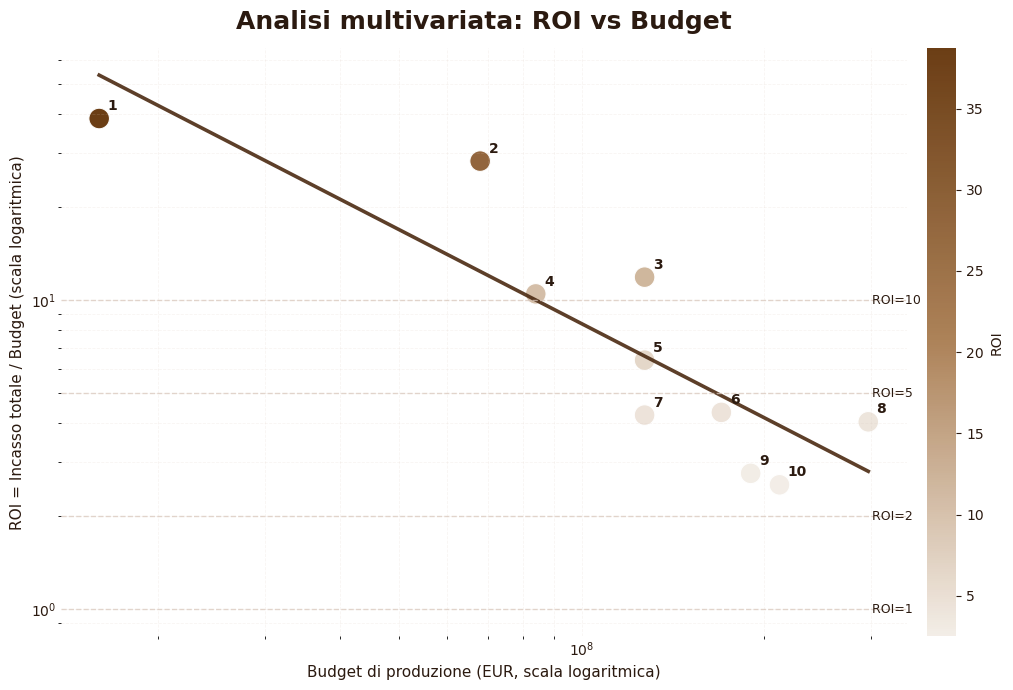

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.colors import LinearSegmentedColormap

def leggi_auto(nome_file):
    raw = pd.read_csv(nome_file)
    raw.drop(columns=[c for c in raw.columns if "Unnamed" in str(c)], inplace=True, errors="ignore")
    raw.columns = raw.columns.astype(str).str.strip()

    need_header_from_first_row = False
    if all(str(c).lower().startswith(("unnamed", "col", "x")) for c in raw.columns):
        need_header_from_first_row = True
    if not any(re.search(r"(film|movie|titolo|nome)", str(c), re.I) for c in raw.columns):
        first = raw.iloc[0].astype(str).str.strip().tolist()
        if any(re.search(r"(film|movie|titolo|nome|budget|incass)", x, re.I) for x in first):
            need_header_from_first_row = True

    if need_header_from_first_row:
        header = raw.iloc[0].astype(str).str.strip().tolist()
        df = raw.iloc[1:].copy()
        df.columns = header
    else:
        df = raw.copy()

    df.drop(columns=[c for c in df.columns if "Unnamed" in str(c)], inplace=True, errors="ignore")
    df.columns = df.columns.astype(str).str.strip()
    return df

def trova_colonna(cols, pattern):
    for c in cols:
        if re.search(pattern, str(c), re.I):
            return c
    return None

def norm_movie(x):
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = re.sub(r"[\(\)\[\]\{\}]", " ", s)
    s = re.sub(r"[^a-z0-9\s:&'\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ["", "-", "nan", "none"]:
        return np.nan
    s = re.sub(r"[€$]", "", s)
    s = s.replace(" ", "")
    s = re.sub(r"[^0-9,\.]", "", s)
    if s == "":
        return np.nan
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    elif s.count(".") > 1 and "," not in s:
        s = s.replace(".", "")
    elif s.count(",") > 1 and "." not in s:
        s = s.replace(",", "")
    else:
        if "," in s and "." not in s:
            s = s.replace(",", ".")
        elif "." in s and "," not in s:
            parts = s.split(".")
            if len(parts) >= 2 and len(parts[-1]) == 3 and all(len(p) <= 3 for p in parts[:-1]):
                s = "".join(parts)
    try:
        return float(s)
    except:
        return np.nan

def parse_budget(x):
    if pd.isna(x):
        return np.nan
    s0 = str(x).strip()
    s = s0.lower().replace("€", "").replace("$", "")
    if s in ["", "-", "nan", "none"]:
        return np.nan
    m = re.search(r"(\d+(?:[.,]\d+)*)", s)
    if not m:
        return np.nan
    num_str = m.group(1).replace(" ", "")
    if "," in num_str and "." in num_str:
        num_str = num_str.replace(".", "").replace(",", ".")
    elif num_str.count(".") > 1 and "," not in num_str:
        num_str = num_str.replace(".", "")
    elif num_str.count(",") > 1 and "." not in num_str:
        num_str = num_str.replace(",", "")
    else:
        if "," in num_str and "." not in num_str:
            num_str = num_str.replace(",", ".")
        elif "." in num_str and "," not in num_str:
            parts = num_str.split(".")
            if len(parts) >= 2 and len(parts[-1]) == 3 and all(len(p) <= 3 for p in parts[:-1]):
                num_str = "".join(parts)
    try:
        v = float(num_str)
    except:
        return np.nan
    if ("miliard" in s) or re.search(r"\b(b|bn)\b", s):
        return v * 1e9
    if ("milion" in s) or re.search(r"\b(m|mn)\b", s):
        return v * 1e6
    if v < 1e4 and ("mil" in s or "mio" in s):
        return v * 1e6
    return v

budget = leggi_auto("Budget.csv")
incassi = leggi_auto("IncassiTot.csv")

col_film_b = trova_colonna(budget.columns, r"(nome.*film|film|movie|titolo)")
col_budget = trova_colonna(budget.columns, r"(budget)")
col_film_i = trova_colonna(incassi.columns, r"(nome.*film|film|movie|titolo)")
col_incasso = trova_colonna(incassi.columns, r"(incass|revenue|box\s*office)")

if col_film_b is None or col_budget is None:
    raise ValueError(f"Budget.csv: non trovo colonne film/budget. Colonne trovate: {list(budget.columns)}")
if col_film_i is None or col_incasso is None:
    raise ValueError(f"IncassiTot.csv: non trovo colonne film/incassi. Colonne trovate: {list(incassi.columns)}")

budget = budget.rename(columns={col_film_b: "Movie", col_budget: "Budget_RAW"})
incassi = incassi.rename(columns={col_film_i: "Movie", col_incasso: "Incasso_RAW"})

budget["Movie"] = budget["Movie"].apply(norm_movie)
incassi["Movie"] = incassi["Movie"].apply(norm_movie)

budget["Budget_EUR"] = budget["Budget_RAW"].apply(parse_budget)
incassi["Incasso_EUR"] = incassi["Incasso_RAW"].apply(parse_money)

budget_ok = budget[["Movie", "Budget_EUR"]].dropna()
budget_ok = budget_ok[budget_ok["Budget_EUR"] > 0]

incassi_ok = incassi[["Movie", "Incasso_EUR"]].dropna()
incassi_ok = incassi_ok[incassi_ok["Incasso_EUR"] > 0]

df = budget_ok.merge(incassi_ok, on="Movie", how="inner")
df["ROI"] = df["Incasso_EUR"] / df["Budget_EUR"]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["ROI"])
df = df[df["ROI"] > 0].copy()

if len(df) < 2:
    bset = set(budget_ok["Movie"].tolist())
    iset = set(incassi_ok["Movie"].tolist())
    print("MATCH=0 o troppo pochi. Film solo in Budget (prime 30):")
    print(sorted(list(bset - iset))[:30])
    print("Film solo in Incassi (prime 30):")
    print(sorted(list(iset - bset))[:30])
    raise ValueError("Dati insufficienti dopo merge: nomi film non allineati tra Budget.csv e IncassiTot.csv (vedi liste stampate).")

df = df.sort_values("ROI", ascending=False).reset_index(drop=True)
df["ID"] = np.arange(1, len(df) + 1)

x = df["Budget_EUR"].astype(float).to_numpy()
y = df["ROI"].astype(float).to_numpy()

logx = np.log10(x)
logy = np.log10(y)
m, b = np.polyfit(logx, logy, 1)

x_line = np.logspace(logx.min(), logx.max(), 200)
y_line = 10 ** (b + m * np.log10(x_line))

cmap_marrone = LinearSegmentedColormap.from_list("marrone", ["#f3ede6", "#a97c50", "#633308"])

fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(
    x, y,
    s=220,
    c=y,
    cmap=cmap_marrone,
    edgecolors="white",
    linewidths=0.8,
    alpha=0.95
)

ax.plot(x_line, y_line, color="#4b2a12", linewidth=2.6, alpha=0.9)

ax.set_xscale("log")
ax.set_yscale("log")

for k in [1, 2, 5, 10]:
    ax.axhline(k, linestyle="--", linewidth=1, color="#d9c8bd", alpha=0.75)
    ax.text(x.max(), k, f" ROI={k} ", va="center", fontsize=9, color="#2b1a10")

ax.set_title("Analisi multivariata: ROI vs Budget", fontsize=18, weight="bold", color="#2b1a10", pad=14)
ax.set_xlabel("Budget di produzione (EUR, scala logaritmica)", fontsize=11, color="#2b1a10")
ax.set_ylabel("ROI = Incasso totale / Budget (scala logaritmica)", fontsize=11, color="#2b1a10")

ax.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.18, color="#d9c8bd")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0, colors="#2b1a10")

for _, r in df.iterrows():
    ax.annotate(
        str(int(r["ID"])),
        (float(r["Budget_EUR"]), float(r["ROI"])),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=10,
        weight="bold",
        color="#2b1a10"
    )

cb = plt.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("ROI", color="#2b1a10")
cb.ax.tick_params(colors="#2b1a10")
cb.outline.set_visible(False)

plt.tight_layout()
plt.show()